# 01 - Data Space

## What evidence did we actually collect?

Data space asks what the finite observations can and cannot support.


Notebook 00 introduced the workshop frame:

$$
\mathcal{H}+\boxed{\mathcal{D}}+\mathcal{O}\rightarrow s.
$$

This notebook slows down at $\mathcal{D}$: the finite evidence the learner actually receives. Before choosing a hypothesis space or objective, we need to ask what structure we gave the dataset and what that structure assumes.

For the running solar-panel problem, we choose supervised pairs $(x_i,y_i)$. That choice says we are trying to learn a function from panel tilt to predicted power output. The rest of the notebook asks what those paired observations reveal about noise, coverage, geometry, sampling design, and what remains underdetermined.


<br>

## 1. Learning objectives

These objectives name the skills to practice in this notebook.


By the end, you should be able to:

1. distinguish the observed dataset $\mathcal{D}$ from the hidden data-generating process;
2. explain how representation, noise, coverage, data-space geometry, and sampling design affect what the learner can infer;
3. identify weakly supported regions in a simple dataset;
4. explain why data alone usually leaves several explanations possible;
5. diagnose whether a modelling issue is currently driven by $\mathcal{D}$, $\mathcal{H}$, or $\mathcal{O}$.


<br>

## 2. Session arc

The route isolates the active learning lever in this notebook.


Route:

1. **Abstract:** the learner receives finite evidence $\mathcal{D}$, not the hidden world.
2. **Concrete:** generate noisy solar-power observations.
3. **Inspect:** vary noise, sample location, coverage, geometry, and repeated measurement.
4. **Diagnose:** identify what the data constrain and what they leave open.
5. Later choices about $\mathcal{H}$ and $\mathcal{O}$ add assumptions where $\mathcal{D}$ is insufficient.

Use this question throughout:

> **What changed, what stayed fixed, and which lever is active: $\mathcal{D}$, $\mathcal{H}$, or $\mathcal{O}$?**


In [1]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

from nextgen2026_mlai_workshops import data, metrics, models, plots

np.set_printoptions(precision=3, suppress=True)


def format_value(value, digits=4):
    """Format numeric values for compact text summaries."""
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value == 0.0:
            return "0"
        if abs(value) < 10 ** (-digits) or abs(value) >= 10_000:
            return f"{value:.2e}"
        return f"{value:.{digits}f}"
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    return str(value)


def print_rows(rows, digits=4, title=None):
    """Print a list of dictionaries as readable summary lines."""
    if title:
        print(title)
    for index, row in enumerate(rows, start=1):
        parts = [f"{key}={format_value(value, digits=digits)}" for key, value in row.items()]
        print(f"{index:02d}. " + ", ".join(parts))


def show_fig(fig):
    display(fig)
    plt.close(fig)


<br>

## 3. Dataset Structure and Assumptions

Representing data as rows decides what the learner can see and what remains hidden.


We record evidence as input-output pairs:

$$
(x_i, y_i) \in \mathcal{X} \times \mathcal{Y},
$$

and collect them into

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n}.
$$

This representation says the task is to explain or predict $y$ from $x$ using a function

$$
h: \mathcal{X} \rightarrow \mathcal{Y}.
$$

That choice decides what the learner can see, what it must predict, and what hidden context is ignored.

Equivalently, $\mathcal{D}$ is a finite sample from a data-generating process:

$$
(x_i,y_i) \sim P_{\mathrm{data}}.
$$

The learner sees the sample, not the full process. The data-space question is: what does this finite tilt-power sample support, and where does it leave room for multiple explanations?

<br>

## 4. A Small Observation World

Finite noisy readings are evidence about the hidden response, not the response itself.


We use a simple simulated solar panel. The panel tilt $x$ runs from 0 to 1, and $y$ is a normalized power output.

The hidden teaching curve is

$$
f^*: \mathcal{X} \rightarrow \mathcal{Y}, \qquad f^*(x)=\sin(\pi x)+0.15\sin(2\pi x).
$$

An observation is a noisy reading near that curve:

$$
y_i = f^*(x_i)+\epsilon_i.
$$

The noise term $\epsilon_i$ stands for sensor noise, irradiance fluctuation, timing differences, shading, cell heating, or panel-soiling variation, or unrecorded context.

The notebook stores evidence as aligned arrays: `x_observed` for panel tilts and `y_observed` for responses. Each aligned pair is one row $(x_i,y_i)$.

This section focuses on noise. Edit the variables, rerun the next cells, and ask what the finite readings alone can support.

> **Try these runs.** Compare low noise, high noise, and `sampling = "partial_domain"`. Predict whether the main limitation is noise or missing coverage.

The hidden curve is shown only because this is a simulation. Hide it when you want the learner's view; reveal it when checking intuition.


### 4.1 Before running: predict what the evidence will show

The next cell creates one finite noisy solar-panel calibration dataset. The hidden response rule is visible only because this is a simulation, so first read the settings as data-space choices.

Before running, write a prediction for each setting:

| Setting | What should become easier or harder to infer? |
|---|---|
| More samples | |
| More noise | |
| Clustered sampling | |
| Partial-domain sampling | |


In [2]:
# Data-space controls. Edit these values and rerun the section.
n_samples = 20
noise_std = 1.00  # Start noisy enough that the pattern is not immediately obvious.
seed = 2026
sampling = "uniform"  # "uniform", "clustered", or "partial_domain"
show_hidden_function = True  # Change to True to reveal the simulation's hidden curve.

x_observed, y_observed = data.make_regression_data(
    n=n_samples,
    noise_std=noise_std,
    seed=seed,
    sampling=sampling,
)

true_at_observed = data.true_function(x_observed)
observation_error = y_observed - true_at_observed
x_gaps = np.diff(np.r_[0.0, x_observed, 1.0])

observable_summary = [
    {
        "n": len(x_observed),
        "x_min": np.min(x_observed),
        "x_max": np.max(x_observed),
        "largest_x_gap": np.max(x_gaps),
        "y_mean": np.mean(y_observed),
        "y_std": np.std(y_observed),
    }
]
print_rows(observable_summary, title="What the learner can read from D")

preview_rows = []
for x, y in zip(x_observed[:8], y_observed[:8]):
    preview_rows.append({"x": x, "observed_y": y})

print()
print_rows(preview_rows, title="First eight rows of D")

simulation_check = [
    {
        "mean_observation_error": np.mean(observation_error),
        "sd_observation_error": np.std(observation_error),
    }
]
print()
print_rows(simulation_check, title="Simulation-only noise check")


What the learner can read from D
01. n=20, x_min=0.1774, x_max=0.9670, largest_x_gap=0.1774, y_mean=0.9252, y_std=0.9247

First eight rows of D
01. x=0.1774, observed_y=0.1862
02. x=0.1789, observed_y=1.3249
03. x=0.2263, observed_y=0.5687
04. x=0.2779, observed_y=0.7653
05. x=0.2983, observed_y=1.5909
06. x=0.3388, observed_y=2.8264
07. x=0.3549, observed_y=0.3033
08. x=0.3705, observed_y=2.3756

Simulation-only noise check
01. mean_observation_error=0.2102, sd_observation_error=0.8776


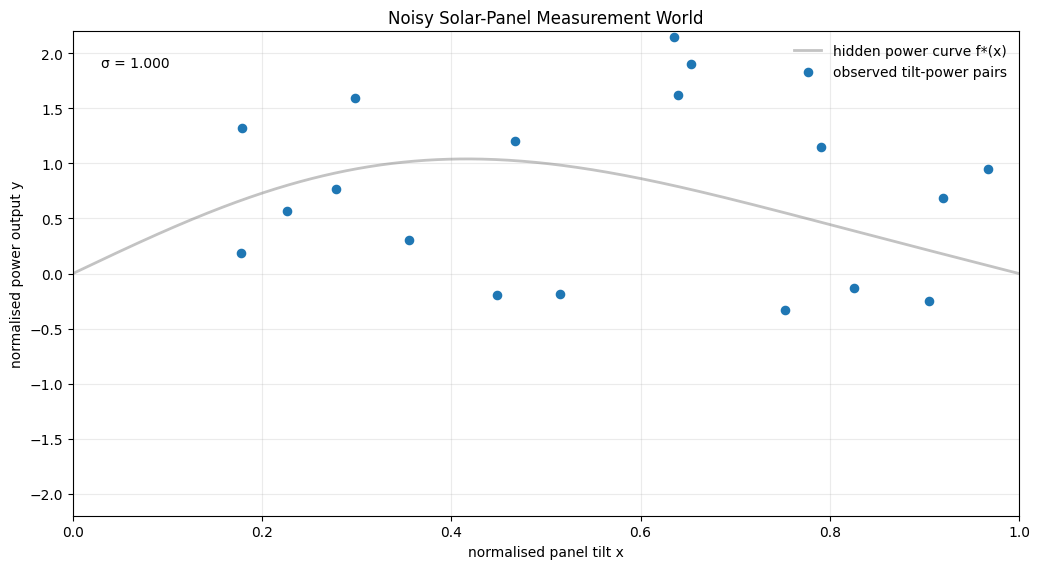

In [3]:
# Visualise the same evidence.
fig = plots.plot_measurement_world(x_observed, y_observed, noise_std=noise_std)
fig.axes[0].set_ylim(-2.2, 2.2)

if not show_hidden_function:
    hidden_line = fig.axes[0].lines[0]
    hidden_line.set_visible(False)
    fig.axes[0].set_title("Noisy observations in D")
    handles, labels = fig.axes[0].get_legend_handles_labels()
    visible = [
        (handle, label)
        for handle, label in zip(handles, labels)
        if label != "true f(x)"
    ]
    if visible:
        handles, labels = zip(*visible)
        fig.axes[0].legend(handles, labels, loc="upper right", frameon=False)

show_fig(fig)

# residual_fig = plots.plot_residual_histogram(x_observed, y_observed)
# show_fig(residual_fig)


### 4.2 After running: read the data as evidence

Inspect the plot before thinking about models.

- Where are observations dense?
- Where are they sparse or missing?
- Does the visible pattern come from $\mathcal{D}$, or from the hidden curve that only the simulation reveals?
- If the hidden curve were removed, what claims would still be defensible?

The dataset is not the world. It is a finite, noisy, unevenly placed sample that will later constrain the hypotheses we can defend.


<br>

## 5. Coverage, Gaps, and Sampling

Where observations sit determines where predictions are locally supported.

Finite observations resolve the power-output curve unevenly. Some tilt regions have nearby samples; others have one noisy point or none.

This is the third data-space diagnostic: coverage. Predictions in well-covered regions are constrained by nearby observations. Predictions in gaps, near boundaries, or outside the sampled range rely more on assumptions.

Before running the comparison, predict which sampling case will have the largest unsupported interval in $x$ and which case will make the right-hand part of the tilt range least defensible.

In the panels below, the shaded band marks the largest one-dimensional $x$ gap.

> **Discuss.** For the solar-panel example, what would count as good tilt coverage: dense settings, repeated readings, edge coverage, or coverage near important operating angles? For higher-dimensional data, what proxy would you inspect?


### 5.1 Before running: predict coverage failures

The next comparison keeps the hidden power-output curve rule, sample size, and noise level fixed while changing which panel tilts are measured. That makes this a data-space intervention.

Fill this table before running:

| Sampling case | Expected strength | Expected weakness | Likely risk |
|---|---|---|---|
| Uniform | | | |
| Clustered | | | |
| Partial domain | | | |


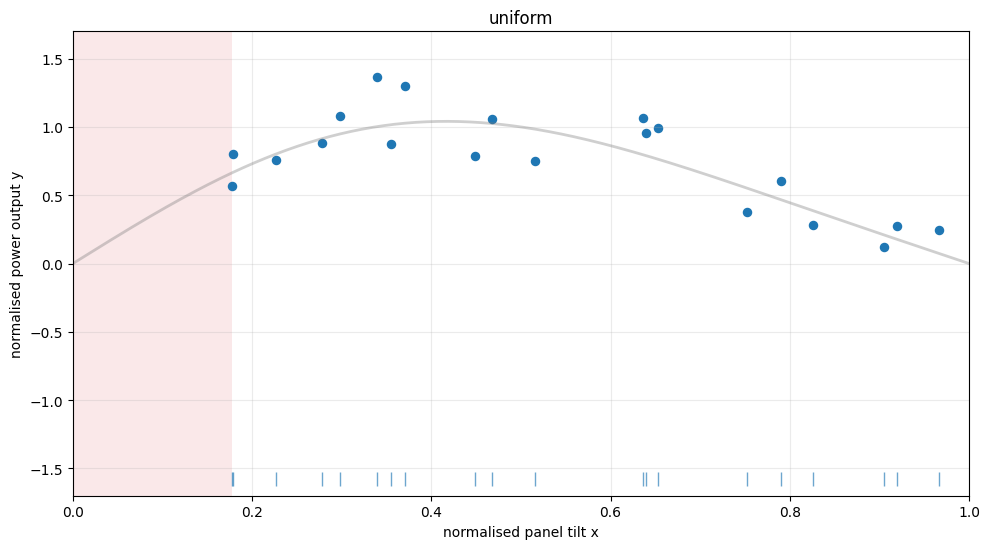

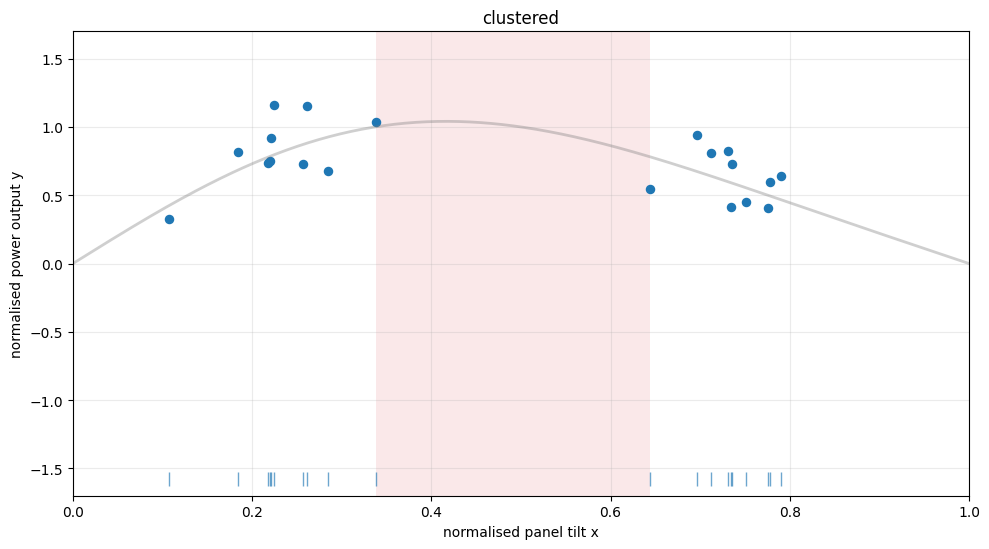

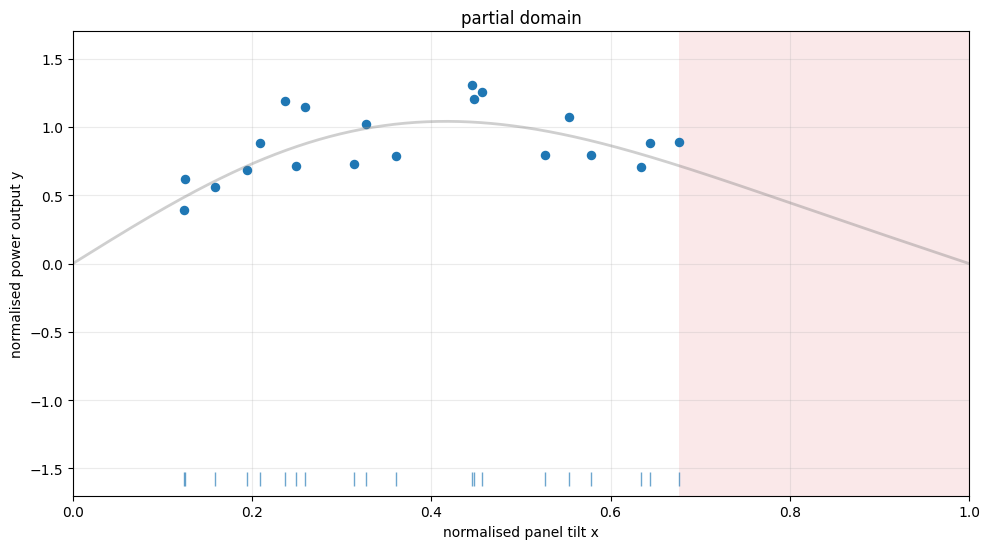

Data-space coverage summaries
01. case=uniform, n=20, x_min=0.1774, x_max=0.9670, largest_gap=0.1774, gap_start=0, gap_end=0.1774
02. case=clustered, n=20, x_min=0.1073, x_max=0.7904, largest_gap=0.3061, gap_start=0.3377, gap_end=0.6438
03. case=partial domain, n=20, x_min=0.1241, x_max=0.6769, largest_gap=0.3231, gap_start=0.6769, gap_end=1.0000


In [4]:
# Compare different ways of observing the same hidden function.
sampling_cases = [
    {"label": "uniform", "n": 20, "noise": 0.20, "sampling": "uniform", "seed": 2026},
    {"label": "clustered", "n": 20, "noise": 0.20, "sampling": "clustered", "seed": 2026},
    {"label": "partial domain", "n": 20, "noise": 0.20, "sampling": "partial_domain", "seed": 2026},
]

x_grid = data.make_test_grid(n_points=500)
coverage_rows = []

for settings in sampling_cases:
    x_case, y_case = data.make_regression_data(
        n=settings["n"],
        noise_std=settings["noise"],
        seed=settings["seed"],
        sampling=settings["sampling"],
    )
    gap_edges = np.r_[0.0, x_case, 1.0]
    gaps = np.diff(gap_edges)
    largest_gap_index = int(np.argmax(gaps))
    gap_start = gap_edges[largest_gap_index]
    gap_end = gap_edges[largest_gap_index + 1]
    coverage_rows.append(
        {
            "case": settings["label"],
            "n": len(x_case),
            "x_min": np.min(x_case),
            "x_max": np.max(x_case),
            "largest_gap": np.max(gaps),
            "gap_start": gap_start,
            "gap_end": gap_end,
        }
    )

    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    ax.axvspan(gap_start, gap_end, color="#d62728", alpha=0.10, linewidth=0)
    ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0)
    ax.scatter(x_case, y_case, color="#1f77b4", s=34)
    ax.plot(x_case, np.full_like(x_case, -1.58), "|", color="#1f77b4", markersize=10, alpha=0.65)
    ax.set_title(settings["label"])
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-1.7, 1.7)
    ax.set_xlabel("normalised panel tilt x")
    ax.set_ylabel("normalised power output y")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    show_fig(fig)

print_rows(coverage_rows, title="Data-space coverage summaries")


### 5.2 After running: diagnose support, then transfer the idea

Read the panels as evidence maps.

- A dense region means nearby predictions may be better constrained.
- A gap means several different functions may still agree with the data while disagreeing between observations.
- A missing domain region means prediction becomes extrapolation.

Coverage is a data-space property. It determines where later model behaviour is supported by observations and where it must rely more heavily on assumptions.

### Transition: from one-dimensional coverage to data-space geometry

So far, coverage was visible because $x$ was one-dimensional. In higher-dimensional problems, coverage is harder to see. 

> Where does the finite evidence sit inside the space of possible observations?


<br>

## 6. Transfer Intuition: Data-Space Geometry

Support means resolving the relevant geometry, not merely collecting more rows.


Coverage is harder to see when $x$ has many dimensions. Row count is not enough; location matters.

The solar-panel example is one-dimensional, so gaps are visible. In richer data, observations often sit near a structured subset of a larger space. Think of meaningful images inside the huge space of all possible pixel arrays, or valid operating states inside all possible sensor readings.

A simple one-dimensional bound shows why spacing and shape both matter. For noiseless function values and a linear interpolant $I_h f$,

$$
\lVert f - I_h f \rVert_\infty \leq \frac{h^2}{8}\max_x |f''(x)|.
$$

Here $h$ is the largest gap between neighbouring samples, and $|f''(x)|$ measures curvature. Large gaps are most risky where the response changes quickly. Flat regions need fewer samples; sharp bends need more.

The higher-dimensional version is the same idea: collect data that resolves the relevant geometry, not just more rows anywhere in the ambient space.

> **Discuss.** What is the structured region in your data, and what would count as good coverage of it?

This is the fourth data-space diagnostic: geometry. Once coverage matters, the next question is how to spend a limited observation budget.


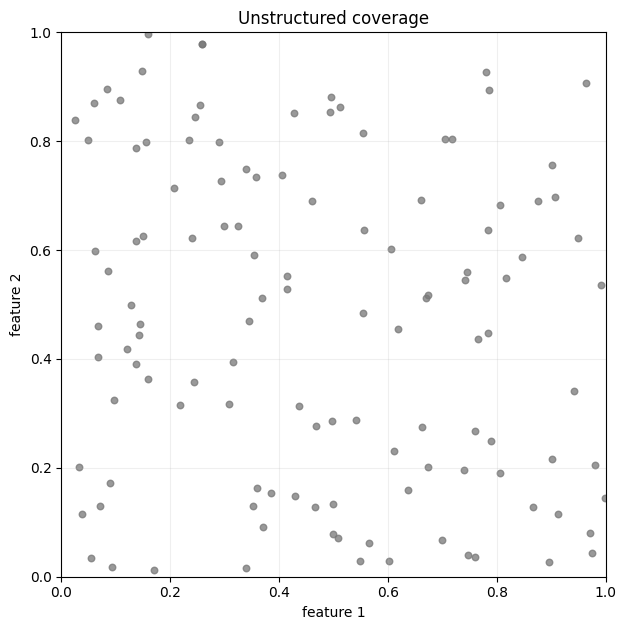

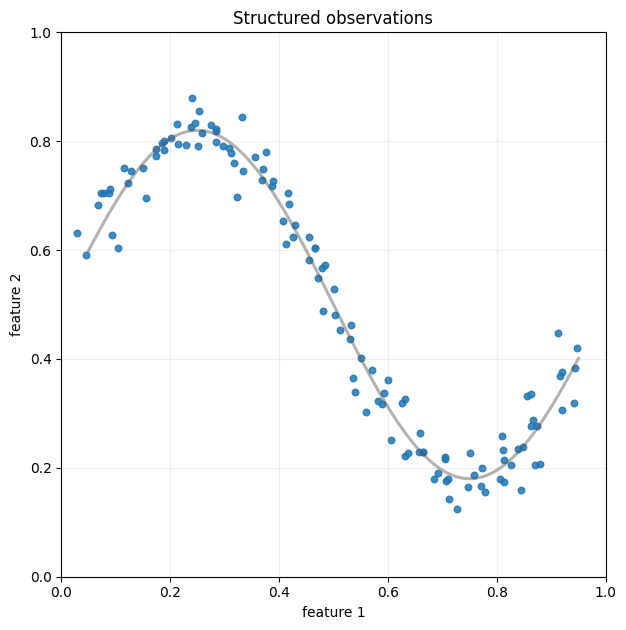

In [5]:
# A 2D sketch of unstructured samples versus samples near a lower-dimensional manifold.
rng = np.random.default_rng(11)
n_points = 120

random_points = rng.uniform(0.0, 1.0, size=(n_points, 2))

curve_t = np.linspace(0.05, 0.95, n_points)
curve_y = 0.50 + 0.32 * np.sin(2.0 * np.pi * curve_t)
structured_points = np.column_stack(
    [
        curve_t + rng.normal(0.0, 0.015, size=n_points),
        curve_y + rng.normal(0.0, 0.035, size=n_points),
    ]
)
structured_points = np.clip(structured_points, 0.0, 1.0)

space_views = [
    ("Unstructured coverage", random_points, None, "#777777", 0.75),
    ("Structured observations", structured_points, (curve_t, curve_y), "#1f77b4", 0.85),
]

for title, points, curve, color, alpha in space_views:
    fig, ax = plt.subplots(figsize=(7.0, 6.4))
    if curve is not None:
        ax.plot(curve[0], curve[1], color="#555555", alpha=0.45, linewidth=2.2)
    ax.scatter(points[:, 0], points[:, 1], s=22, color=color, alpha=alpha)
    ax.set_title(title)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.grid(alpha=0.20)
    fig.tight_layout()
    show_fig(fig)


### 6.1 After running: compare row count with geometry

Both panels contain the same number of measurements, but they describe different data spaces.

- Random points spread across the ambient box.
- Structured points concentrate near a lower-dimensional pattern.
- Equal row count does not imply equal support for the task-relevant region.

Data quantity is not the same as data support. A dataset can have many rows and still leave the relevant structure weakly covered.


<br>

## 7. Coverage Versus Repeated Measurement

A fixed measurement budget trades broad coverage against repeated local evidence.


The geometry section asked where observations sit. The design question asks how those observations got allocated. With a fixed solar-panel measurement budget, we often trade coverage against repetition.

Sampling many distinct locations helps resolve the shape of the signal across the domain. Repeating observations at fewer locations helps estimate local variation and noise. In the observation model $y_i=f^*(x_i)+\epsilon_i$, repeated measurements at the same $x$ give direct evidence about the local mean and the spread of $\epsilon_i$ around that point. They can reduce uncertainty about function behaviour nearby, but they do less to resolve gaps elsewhere.

This is the fifth data-space diagnostic: design. Neither design is automatically better. The right choice depends on the scientific or decision question: do we need to map the function broadly, estimate uncertainty at a few critical settings, or improve evidence near a boundary where decisions are sensitive?

Before running the next cell, predict which design will have more unique $x$ values, which will give direct evidence about local noise, and which will leave fewer unsupported regions across the full domain.

> **Discuss.** In your own work, where would the next observation change the decision most: an under-sampled region, a high-stakes boundary, a repeated measurement at a noisy setting, or a subgroup whose behaviour you do not yet trust?

The next cell uses the same number of observations in two designs. One spreads observations across the domain. The other repeats measurements at a smaller number of locations.


### 7.1 Before running: choose a measurement strategy

With a fixed solar-panel measurement budget, there is a trade-off. Predict what each design buys before looking at the plots.

| Strategy | What it helps estimate | What it may leave weak |
|---|---|---|
| Spread observations broadly | | |
| Repeat measurements at fewer locations | | |


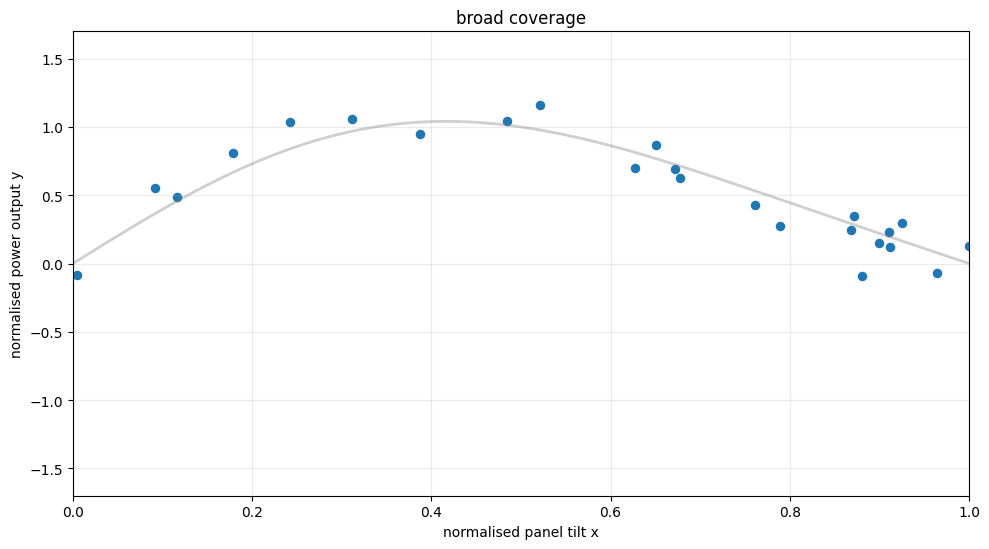

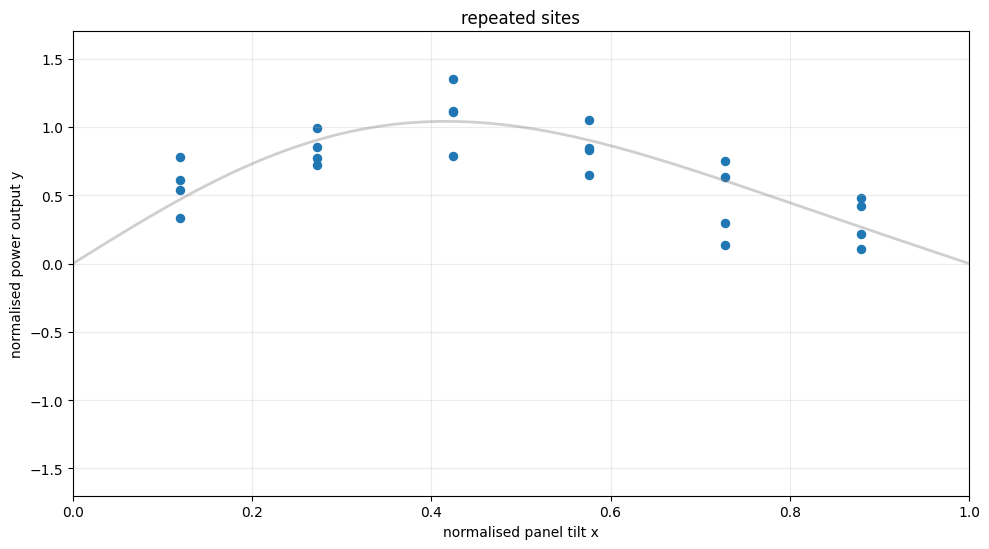

Fixed-budget design summaries
01. design=broad coverage, n=24, unique_x=24, largest_gap=0.1065, y_std=0.3837
02. design=repeated sites, n=24, unique_x=6, largest_gap=0.1520, y_std=0.3168

What repeated observations reveal locally
01. x=0.1200, n_repeats=4, local_mean_y=0.5676, local_sd_y=0.1855
02. x=0.2720, n_repeats=4, local_mean_y=0.8359, local_sd_y=0.1163
03. x=0.4240, n_repeats=4, local_mean_y=1.0896, local_sd_y=0.2298
04. x=0.5760, n_repeats=4, local_mean_y=0.8439, local_sd_y=0.1649
05. x=0.7280, n_repeats=4, local_mean_y=0.4539, local_sd_y=0.2834
06. x=0.8800, n_repeats=4, local_mean_y=0.3050, local_sd_y=0.1743


In [6]:
# Compare two fixed-budget data designs: broad coverage versus repeated observations.
observation_budget = 24
noise_std_design = 0.18
rng = np.random.default_rng(34)

x_broad = np.sort(rng.uniform(0.0, 1.0, size=observation_budget))
y_broad = data.true_function(x_broad) + rng.normal(0.0, noise_std_design, size=observation_budget)

repeat_sites = np.linspace(0.12, 0.88, 6)
repeats_per_site = observation_budget // len(repeat_sites)
x_repeated = np.repeat(repeat_sites, repeats_per_site)
y_repeated = data.true_function(x_repeated) + rng.normal(0.0, noise_std_design, size=len(x_repeated))

designs = [
    ("broad coverage", x_broad, y_broad),
    ("repeated sites", x_repeated, y_repeated),
]

for label, x_design, y_design in designs:
    fig, ax = plt.subplots(figsize=(10.0, 5.6))
    ax.plot(x_grid, data.true_function(x_grid), color="#777777", alpha=0.35, linewidth=2.0)
    ax.scatter(x_design, y_design, color="#1f77b4", s=34)
    ax.set_title(label)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-1.7, 1.7)
    ax.set_xlabel("normalised panel tilt x")
    ax.set_ylabel("normalised power output y")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    show_fig(fig)

summary_rows = []
for label, x_design, y_design in designs:
    gaps = np.diff(np.r_[0.0, np.unique(x_design), 1.0])
    summary_rows.append(
        {
            "design": label,
            "n": len(x_design),
            "unique_x": len(np.unique(x_design)),
            "largest_gap": np.max(gaps),
            "y_std": np.std(y_design),
        }
    )

print_rows(summary_rows, title="Fixed-budget design summaries")

repeat_rows = []
for x_site in repeat_sites:
    local_y = y_repeated[x_repeated == x_site]
    repeat_rows.append(
        {
            "x": x_site,
            "n_repeats": len(local_y),
            "local_mean_y": np.mean(local_y),
            "local_sd_y": np.std(local_y, ddof=1),
        }
    )

print()
print_rows(repeat_rows, title="What repeated observations reveal locally")


<br>

## 8. Summary: What D Can and Cannot Decide

The dataset constrains explanations but does not select a final model by itself.


1. **Representation defines the rows.** It decides what the learner can use and what stays hidden.
2. **Noise blurs the signal.** Real readings vary around the underlying process.
3. **Coverage decides where evidence is local.** Gaps and missing regions make prediction rely more on assumptions.
4. **Geometry decides what coverage means.** In high dimensions, use slices, neighbours, embeddings, subgroups, or deployment scenarios as support checks.
5. **Design allocates the observation budget.** Broad coverage and repeated measurements answer different questions.
6. **Underdetermination remains.** Many hidden functions can agree with the collected rows and disagree elsewhere.

> **Discuss.** What are $x$ and $y$ in your problem, and what is lost when the world is forced into that representation?

> **Discuss.** Which variation is signal, which is noise, and how would you know from the data alone?

> **Discuss.** What assumptions must $\mathcal{H}$ or $\mathcal{O}$ add because the data do not decide the question?

First principle: learning begins with evidence. The data space defines what the learner gets to use.


<br>

## 9. Data-Space Diagnostic Checklist

Use the checklist to summarize what the evidence supports before choosing a model.


Before choosing a model, use this checklist to summarize what $\mathcal{D}$ can and cannot decide.

| Diagnostic | Question | Modelling implication |
|---|---|---|
| Representation | What is one row, tilt setting, and power output? | Defines what the learner can use and what is hidden. |
| Noise | How variable are repeated or nearby observations? | Limits confidence in fitted structure. |
| Coverage | Where is evidence dense, sparse, or missing? | Controls where predictions are locally supported. |
| Data-space geometry | What structured region of the possible setting space matters? | Prevents row count from being mistaken for support. |
| Design | How were observations allocated? | Determines whether data reduce the uncertainty that matters. |
| Underdetermination | What remains compatible with the observations? | Explains why $\mathcal{H}$ and $\mathcal{O}$ are still needed. |

> **Synthesis task.** For your own calibration or measurement dataset, identify one thing that changed during this notebook, one thing that stayed fixed, and the active lever in each section: $\mathcal{D}$, $\mathcal{H}$, or $\mathcal{O}$.

**Takeaway.** $\mathcal{D}$ constrains possible explanations, but it does not select a final model by itself.


<br>

## 10. Bridge to Notebook 02

Once evidence is fixed, the next question is what explanations are allowed.


This notebook did not choose a curve. It asked what $\mathcal{D}$ contains: representation, noise, coverage, geometry, design, and gaps.

Notebook 02 keeps the same solar-panel observation world and changes focus from evidence to possibility. Once $\mathcal{D}$ is fixed, the next question is $\mathcal{H}$: which functions are allowed to explain these rows?


<br>

## 11. References

These references support the data-space and evaluation ideas used here.


- Shalev-Shwartz, S., & Ben-David, S. (2014). [*Understanding Machine Learning: From Theory to Algorithms*](https://www.cambridge.org/core/books/understanding-machine-learning/3059695661405D25673058E43C8BE2A6). Formal language for data distributions, datasets, hypothesis classes, loss functions, and empirical risk minimisation.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). [*The Elements of Statistical Learning: Data Mining, Inference, and Prediction*](https://link.springer.com/book/10.1007/978-0-387-84858-7), 2nd ed. Supervised regression, model assessment, and train/test reasoning.
- Bengio, Y., Courville, A., & Vincent, P. (2013). [*Representation Learning: A Review and New Perspectives*](https://arxiv.org/abs/1206.5538), *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 35(8), 1798-1828. Manifold and representation-learning framing for high-dimensional data.
